In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import numpy as np
from typing import Dict, Iterable, Optional
from datetime import datetime
from Simulation import Simulation 
import Plots 


#
plots = Plots.Plots()

# STratified Sampling 


1. Call and set _Simulation_ for the purpose of the stratified sampling.
2. The class _Simulation_ simulate a sampling scenario (namely, generate, sample and evaluate the estimators with respect to the sampling design)
3. The initiization of _Simulation_ will account for two strategies, STS and MFS. In this context, only the latter will be considered
4. Evaluate two true observables, that is, the sum population and the Population in each stratum

In [2]:
#This simulation concerns the stratified sampling only

#this serves to initialize the Simulation Class -- proportional strategy
simulation = Simulation(allocation="proportional", strategy= "StS")
simulation_init_results = simulation.run_pipeline()

#this serves to initialize the Simulation Class -- optimal cot strategy
simulation_opt = Simulation(allocation="optimal_cost", strategy= "StS")
simulation_init_results_opt = simulation_opt.run_pipeline()

#get the true observables
Y_true = np.sum(simulation_init_results["population"]["y"])
Nq_true_equal = np.sum(simulation_init_results["population"]["Nq"])

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Optimal Cost Allocation -- Extraction Stratified Sampling:
nq -- Sample size per frame: [345, 330, 327]
Sampling fraction per frame: [0.3440307  0.32956298 0.32640632]
----------------------
Optimal Cost Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [213 171 217]
Sampling fraction per frame: [0.35472055 0.2838148  0.36146465]
----------------------


In [3]:
#inital time
dinit = datetime.now()
R = 25 #number of MonteCarlo runs

#Save the estimates
estimates = {
     "Y_STS": np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="StS").run_pipeline()["estimates"]["Y_STS"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="StS").run_pipeline()["estimates"]["Y_STS"] for rr in range(R)])]),
      'Var_Y_STS': np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="StS").run_pipeline()["estimates"]["Var_Y_STS"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="StS").run_pipeline()["estimates"]["Var_Y_STS"] for rr in range(R)])]),
       "mu_STS" :  np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="StS").run_pipeline()["estimates"]["mu_STS"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="StS").run_pipeline()["estimates"]["mu_STS"] for rr in range(R)])]),
        }


#Save the allocations
allocations = np.hstack([np.repeat("proportional", R), np.repeat("optimal_cost", R)])  # e.g., ["prop-x", "equal", "cost-opt", ...] per run
#time final
dfinal = datetime.now()
print(dfinal-dinit)

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation:
Nq -- Total per frame: [ 990  990 1020]
nq -- Sample size per frame: [198. 198. 204.]
Sampling fraction per frame: 0.2
----------------------
Proportional Allocation -- Extraction:
nq -

In [4]:
# Evaluate the MSE
DF = pd.DataFrame(estimates)
DF["allocation"] = allocations
true_value = 1

DFgb = DF.groupby("allocation")
for key, index in DFgb:
    dg= DFgb.get_group(key)
    mse = (dg["mu_STS"] -1)**2
    bootstrap_result = bootstrap((mse,), np.mean)

    print("===================================")
    print(f" === {key} ===")
    print(mse.mean())
    print(bootstrap_result.confidence_interval.low)
    print(bootstrap_result.confidence_interval.high)
    print('===================================')

 === optimal_cost ===
9.535136003310958e-06
6.030907640156535e-06
1.4152693635086261e-05
 === proportional ===
8.402115969466542e-06
5.150948896087115e-06
1.4404065011402667e-05


c:\Users\glancia\Documents\-Population-Detection-and-Sampling-in-Liguria\Simulation\Plots.py:180: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  ax = sns.boxplot(


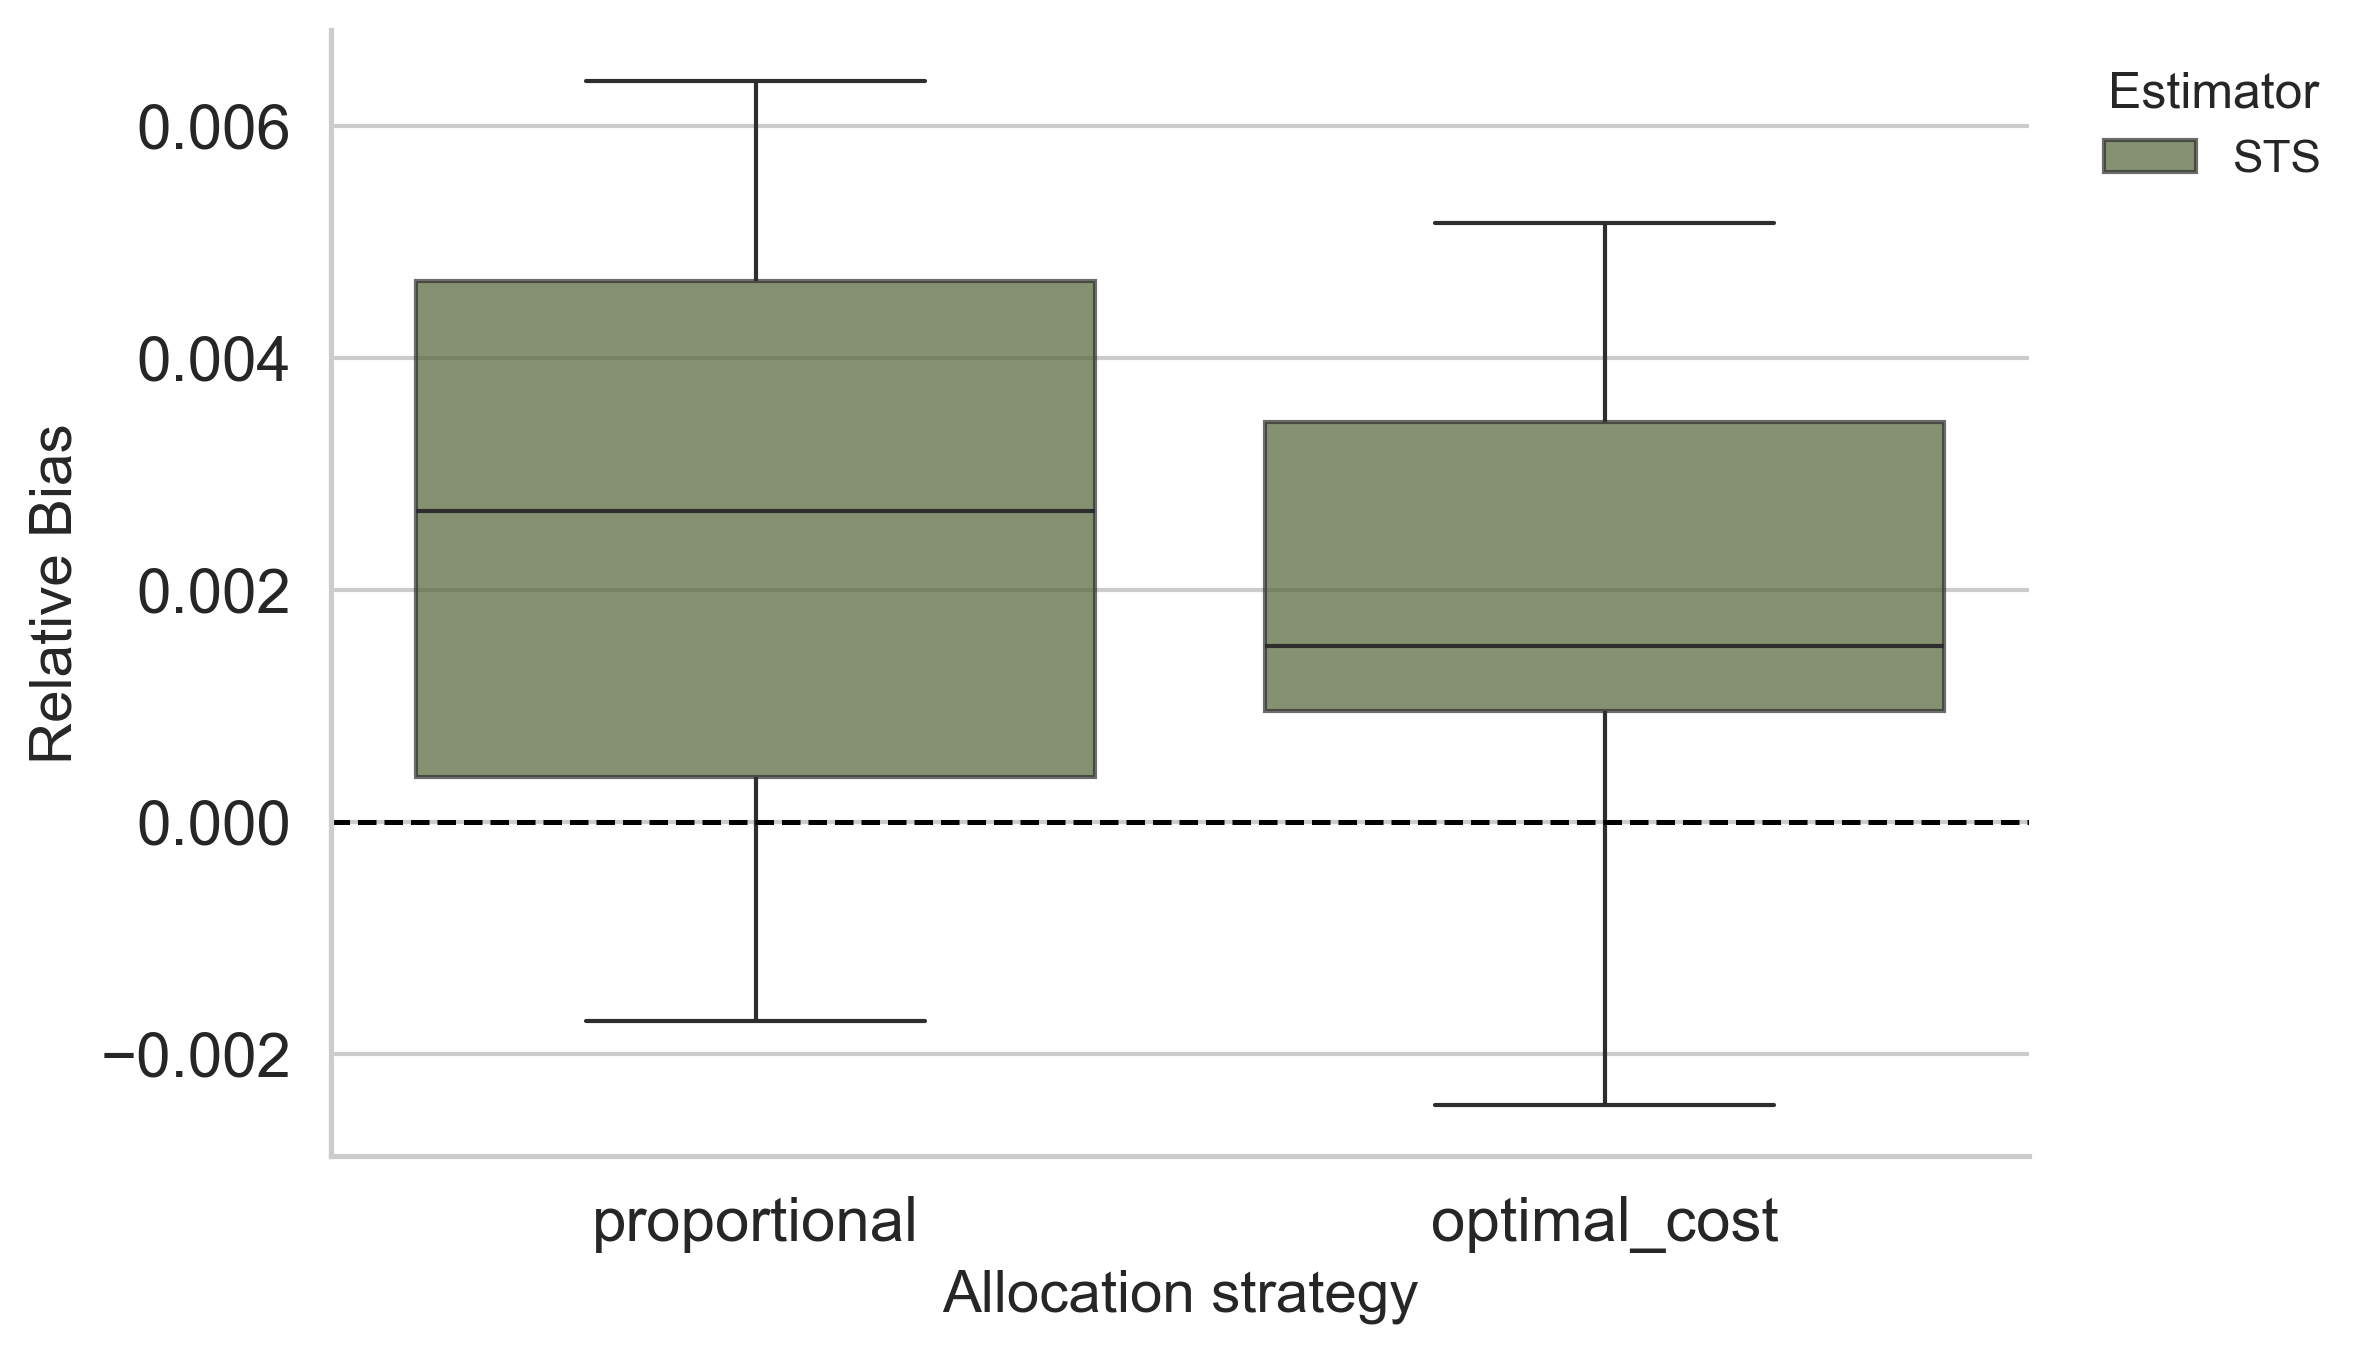

     allocation Estimator         MSE     CI_low     CI_high   n
0  optimal_cost       STS   61.952501  35.519818   91.595755  25
1  proportional       STS  115.687028  72.666404  162.768712  25


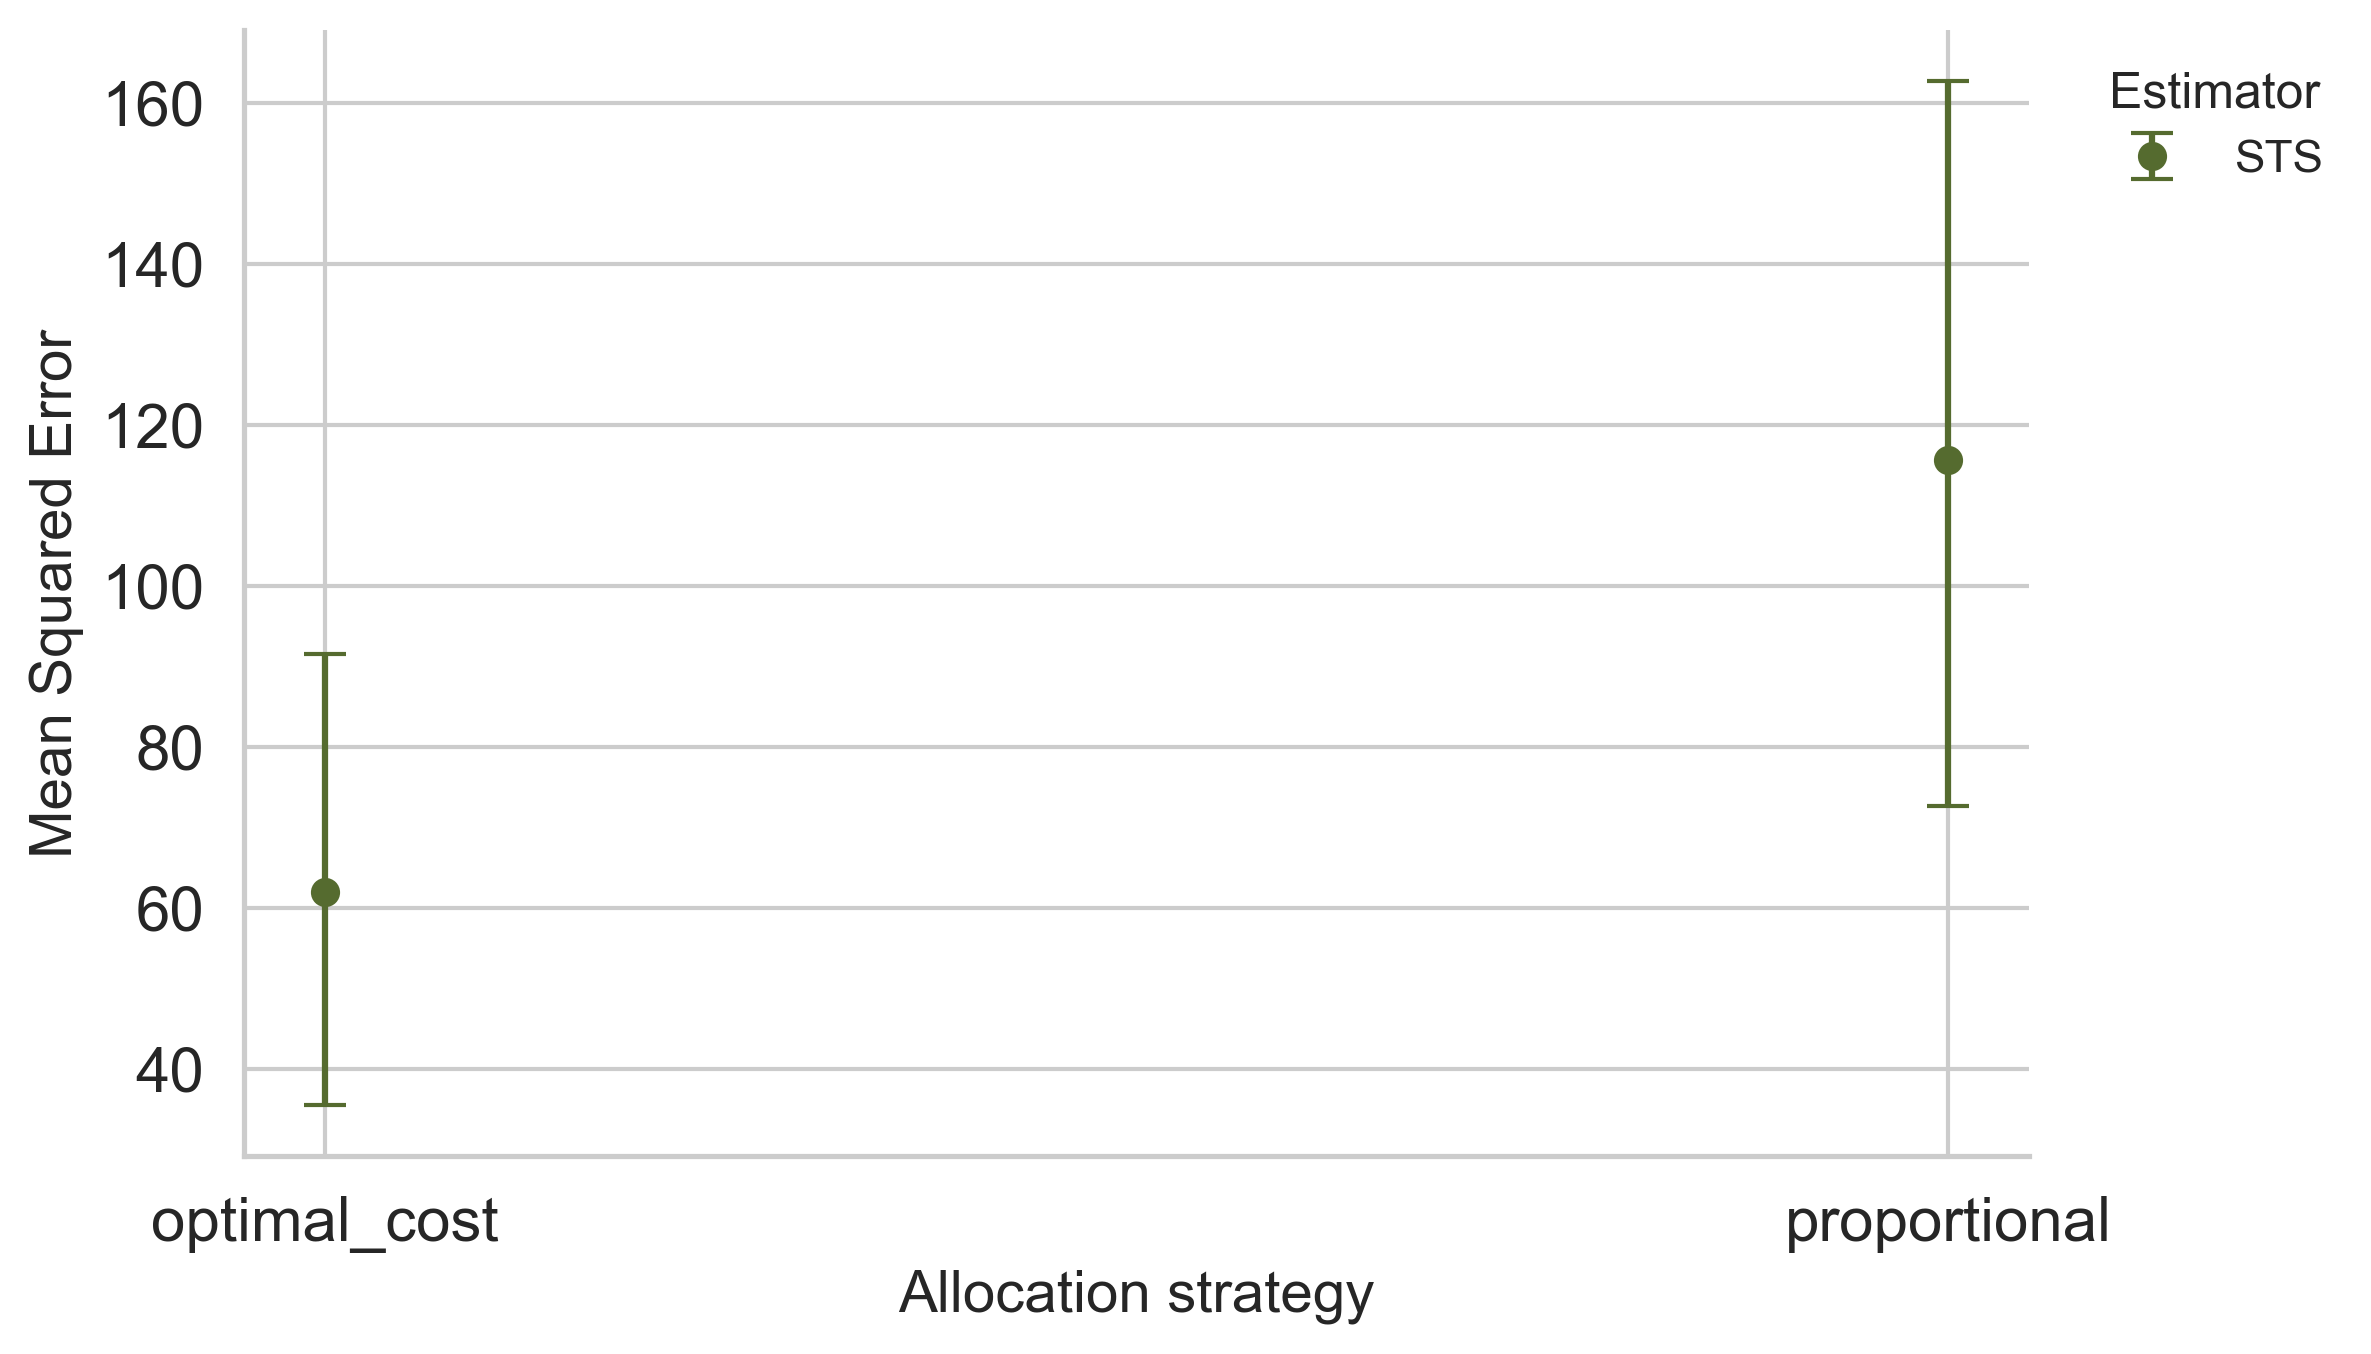

In [5]:
plots.plot_relative_error(estimates, Y_true, allocations, save="KSTS_relative_bias.pdf", kind = "STS")
plots.plot_mse(estimates, Y_true, allocations, save="KSTS_mse.pdf", kind = "STS")

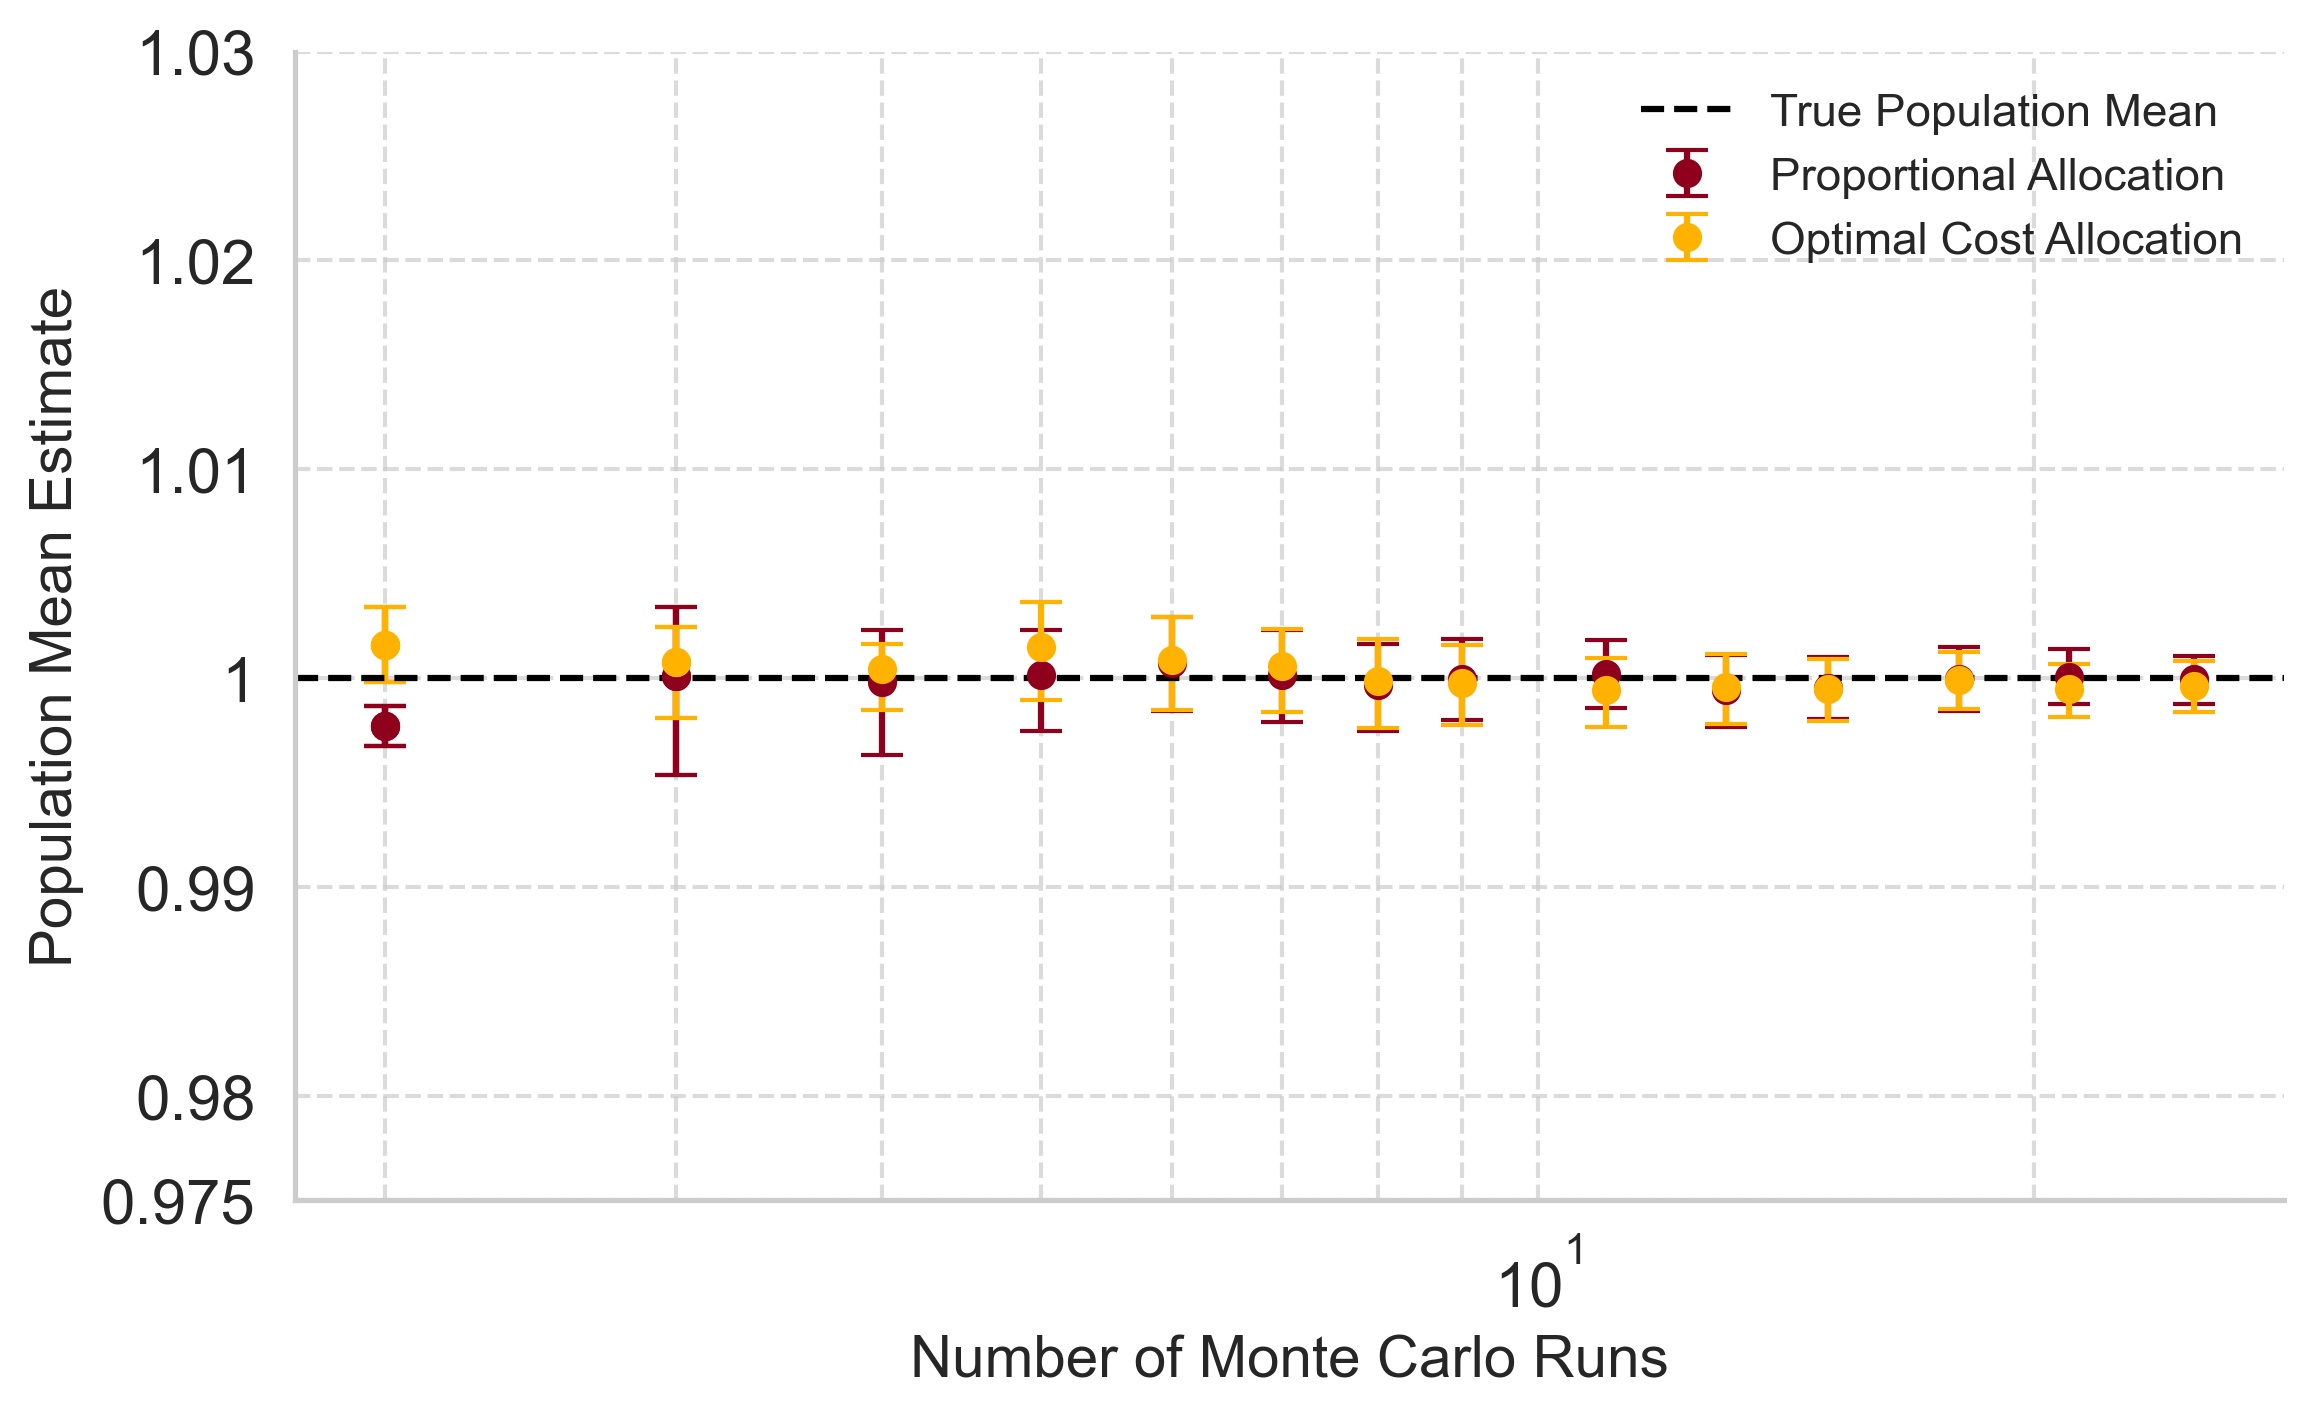

{'batch_sizes': array([ 2,  2,  2,  3,  3,  4,  5,  6,  7,  8,  9, 11, 13, 15, 18, 21, 25]),
 'prop': array([[0.99772496, 0.99676883, 0.9986811 ],
        [0.99772496, 0.99676883, 0.9986811 ],
        [0.99772496, 0.99676883, 0.9986811 ],
        [1.00008148, 0.99536844, 1.00339413],
        [1.00008148, 0.99536844, 1.00339413],
        [0.99979842, 0.99633068, 1.00228291],
        [1.00012411, 0.99747119, 1.00227839],
        [1.00071807, 0.99840624, 1.00293483],
        [1.00013297, 0.99791708, 1.00228885],
        [0.99967265, 0.99744856, 1.00164508],
        [0.99996246, 0.99797674, 1.00187532],
        [1.00019794, 0.99854534, 1.00183056],
        [0.99942256, 0.997673  , 1.00110317],
        [0.99953797, 0.99802708, 1.0010229 ],
        [0.99997671, 0.99843781, 1.00148031],
        [1.00005698, 0.99874188, 1.00138998],
        [0.99993321, 0.99876356, 1.00104149]]),
 'opt': array([[1.00160132, 0.99979115, 1.00341149],
        [1.00160132, 0.99979115, 1.00341149],
        [1.00160

In [6]:
#analysis of population mean -- how and whether Monte Carlo results converges to the true value
plots.analyze_population_mean(
        estimates = estimates,
        R = R,
        true_value = 1, 
        save_path = "KSTS_population_mean.pdf", 
        kind = "STS")

In [7]:
#This simulation concerns the MFS sampling
#this serves to initialize
simulation = Simulation(allocation="proportional", strategy= "MFS")
simulation_init_results = simulation.run_pipeline()

simulation_opt = Simulation(allocation="optimal_cost", strategy= "MFS")
simulation_init_results_opt = simulation_opt.run_pipeline()


Y_true = np.sum(simulation_init_results["population"]["y"])
Nq_true_equal = np.sum(simulation_init_results["population"]["Nq"])

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Optimal Cost Allocation -- Extraction Multi-Frame Sampling:
nq -- Sample size per frame: [262, 414, 327]
Sampling fraction per frame: [0.26124821 0.41272257 0.32602922]
----------------------


In [8]:
# Suppose you have arrays from R runs with the same length:
R = 25
estimates = {
     "mu_SM": np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="MFS").run_pipeline()["estimates"]["mu_SM"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="MFS").run_pipeline()["estimates"]["mu_SM"] for rr in range(R)])]),
     "mu_PML": np.hstack([np.array([Simulation(reproduce=False, allocation= "proportional", strategy="MFS").run_pipeline()["estimates"]["mu_PML"] for rr in range(R)]), 
                       np.array([Simulation(reproduce=False, allocation= "optimal_cost", strategy="MFS").run_pipeline()["estimates"]["mu_PML"] for rr in range(R)])])
      
}

allocations = np.hstack([np.repeat("proportional", R), np.repeat("optimal_cost", R)])  # e.g., ["prop-x", "equal", "cost-opt", ...] per run

Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Sampling fraction per frame: [0.2, 0.2, 0.2]
----------------------
Proportional Allocation -- Extraction:
nq -- Sample size per frame: [198, 198, 204]
Samp

In [9]:
# Evaluate the MSE
DF = pd.DataFrame(estimates)
DF["allocation"] = allocations
true_value = 1

DFgb = DF.groupby("allocation")
for key, index in DFgb:
    dg= DFgb.get_group(key)
    mse = (dg["mu_SM"] -1)**2
    bootstrap_result = bootstrap((mse,), np.mean)

    print("===================================")
    print(f" === {key} ===")
    print(mse.mean())
    print(bootstrap_result.confidence_interval.low)
    print(bootstrap_result.confidence_interval.high)
    print('===================================')


DFgb = DF.groupby("allocation")
for key, index in DFgb:
    dg= DFgb.get_group(key)
    mse = (dg["mu_PML"] -1)**2
    bootstrap_result = bootstrap((mse,), np.mean)

    print("===================================")
    print(f" === {key} ===")
    print(mse.mean())
    print(bootstrap_result.confidence_interval.low)
    print(bootstrap_result.confidence_interval.high)
    print('===================================')

 === optimal_cost ===
0.00013508412299497659
9.51432044935362e-05
0.00020987768176738858
 === proportional ===
0.0002677935882057987
0.00016531245494436306
0.00041093795892305197
 === optimal_cost ===
0.00015504140836510117
9.789434773740892e-05
0.0002333594747007327
 === proportional ===
0.00020883806888026535
0.00011885785368377359
0.00038378279711404815


In [10]:
plots.analyze_population_mean(
        estimates = estimates,
        R = R,
        true_value = 1000, 
        save_path = "KSM_analysis_population_mean.pdf",
        kind = "SM")


plots.analyze_population_mean(
        estimates = estimates,
        R = R,
        true_value = 1000, 
        save_path = "KPML_analysis_population_mean.pdf",
        kind = "PML")

KeyError: 'Y_SM'

In [ ]:
plots.plot_relative_error(estimates, Y_true, allocations, save="KMF_relative_bias.pdf")

In [ ]:
plots.plot_mse(estimates, Y_true, allocations, save="KMF_MSE.pdf")

In [ ]:
sys.exit()

In [ ]:
def frame_size_reconstruction(realizations, modalities, true_values, n_boot=2000, ci_level=0.95, save: Optional[str] = None):
    """
    Compare realizations of x (N samples x M variables) with true values y.
    Computes mean and bootstrap CI per modality and variable.
    
    Parameters
    ----------
    realizations : ndarray (N x M)
        Realizations of x values.
    modalities : array-like (length N)
        Labels indicating modality of each row.
    true_values : array-like (length M)
        True reference values y1..yM.
    n_boot : int, optional
        Number of bootstrap resamples.
    ci_level : float, optional
        Confidence interval level (default 0.95).
        
    Returns
    -------
    df_summary : DataFrame
        Mean, CI, and comparison with truth for each modality-variable.
    """
    N, M = realizations.shape
    modalities = np.array(modalities)
    true_values = np.array(true_values)
    
    results = []
    for mod in np.unique(modalities):
        mod_idx = modalities == mod
        X_mod = realizations[mod_idx]  # subset
        
        for j in range(M):
            col = X_mod[:, j]
            
            # bootstrap CI for the mean
            boot_res = bootstrap(
                (col,), 
                np.mean, 
                confidence_level=ci_level, 
                n_resamples=n_boot, 
                method="percentile"
            )
            
            mean_val = np.mean(col)
            ci_low, ci_high = boot_res.confidence_interval
            
            results.append({
                "allocation": mod,
                "frame": f"frame_{j+1}",
                "mean_x": mean_val,
                "ci_low": ci_low,
                "ci_high": ci_high
            })
    
    df_summary = pd.DataFrame(results)
    df_summary["true_y"] = true_values
    
    # Plotting: scatter with CI bars
    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=df_summary, x="mean_x", y="true_y", hue="allocation", style="frame", s=100)
    
    # error bars for CI
    for _, row in df_summary.iterrows():
        plt.plot([row["ci_low"], row["ci_high"]], [row["true_y"]]*2, color="gray", lw=2)
    
    # 45 degree line
    lims = [
        min(df_summary["mean_x"].min(), df_summary["true_y"].min()),
        max(df_summary["mean_x"].max(), df_summary["true_y"].max())
    ]
    plt.plot(lims, lims, "--", color="black")
    plt.xlabel("Mean Nhat_q (with CI)")
    plt.ylabel("True value")
    plt.title("Comparison of Realizations vs True Values")
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()

    
    
    return df_summary


frame_size_reconstruction(estimates["N_hatq"], allocations,
                          np.hstack([np.array([len(item) for item in simulation_init_results ["population"]["frames"]]), 
                                     np.array([len(item) for item in simulation_init_results_opt ["population"]["frames"]])]),
                         save = "frame_size_reconstruction.pdf")

In [ ]:
np.array([len(item) for item in simulation_init_results ["population"]["frames"]])

In [ ]:
def domain_size_reconstruction(realizations, modalities, true_values, n_boot=2000, ci_level=0.95, save: Optional[str] = None):
    """
    Compare realizations of x (N samples x M variables) with true values y.
    Computes mean and bootstrap CI per modality and variable.
    
    Parameters
    ----------
    realizations : ndarray (N x M)
        Realizations of x values.
    modalities : array-like (length N)
        Labels indicating modality of each row.
    true_values : array-like (length M)
        True reference values y1..yM.
    n_boot : int, optional
        Number of bootstrap resamples.
    ci_level : float, optional
        Confidence interval level (default 0.95).
        
    Returns
    -------
    df_summary : DataFrame
        Mean, CI, and comparison with truth for each modality-variable.
    """
    N, M = realizations.shape
    modalities = np.array(modalities)
    true_values = np.array(true_values)
    
    results = []
    for mod in np.unique(modalities):
        mod_idx = modalities == mod
        X_mod = realizations[mod_idx]  # subset
        
        for j in range(M):
            col = X_mod[:, j]
            
            # bootstrap CI for the mean
            boot_res = bootstrap(
                (col,), 
                np.mean, 
                confidence_level=ci_level, 
                n_resamples=n_boot, 
                method="percentile"
            )
            
            mean_val = np.mean(col)
            ci_low, ci_high = boot_res.confidence_interval
            
            results.append({
                "allocation": mod,
                "frame": f"frame_{j+1}",
                "mean_x": mean_val,
                "ci_low": ci_low,
                "ci_high": ci_high
            })
    
    df_summary = pd.DataFrame(results)
    df_summary["true_y"] = true_values
    
    # Plotting: scatter with CI bars
    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=df_summary, x="mean_x", y="true_y", hue="allocation", style="frame", s=100)
    
    # error bars for CI
    for _, row in df_summary.iterrows():
        plt.plot([row["ci_low"], row["ci_high"]], [row["true_y"]]*2, color="gray", lw=2)
    
    # 45 degree line
    lims = [
        min(df_summary["mean_x"].min(), df_summary["true_y"].min()),
        max(df_summary["mean_x"].max(), df_summary["true_y"].max())
    ]
    plt.plot(lims, lims, "--", color="black")
    plt.xlabel("Mean NPML_d (with CI)")
    plt.ylabel("True value")
    plt.title("Comparison of Domain Size Reconstruction")
    if save:
        plt.savefig(save, bbox_inches="tight")
    plt.show()

    
    
    return df_summary

domain_size_reconstruction(estimates["NPML_d"], allocations,
                           np.hstack([np.array([len(item) for item in simulation_init_results ["population"]["domains"]]), 
                                     np.array([len(item) for item in simulation_init_results_opt ["population"]["domains"]])]),
                          save = "domain_size_reconstruction.pdf")

In [ ]:
def plot_weights_histograms(data_dict, dataset_name, bins=20, normalize=False, save: Optional[str] = None):
    """
    Plot histograms per group and modality from a nested dictionary of data.
    
    Parameters
    ----------
    data_dict : dict
        Dictionary of the form:
        {
          "group1": {"mod1": array_like, "mod2": array_like, ...},
          "group2": {"mod1": array_like, ...},
          ...
        }
    dataset_name : str
        Name of the dataset (used for plot title).
    bins : int, optional
        Number of histogram bins (default=20).
    normalize : bool, optional
        If True, normalize histograms to density instead of counts.
    """
    # ---- reshape to tidy DataFrame ----
    rows = []
    for group, mod_dict in data_dict.items():
        for mod, vals in mod_dict.items():
            for v in vals:
                rows.append([dataset_name, group, mod, v])
    df = pd.DataFrame(rows, columns=["dataset", "group", "modality", "value"])
    
    # ---- plotting ----
    g = sns.FacetGrid(
        df, col="group", col_wrap=3, sharex=False, sharey=False, height=4
    )
    g.map_dataframe(
        sns.histplot,
        x="value",
        hue="modality",
        multiple="dodge",   # side-by-side bars
        bins="auto",
        stat="density" if normalize else "count",  # counts or density
        shrink=0.8
    )
    g.add_legend()
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Histograms of {dataset_name} per allocation", y=1.05)

    if save:
        plt.savefig(save, bbox_inches= "tight")
    
    plt.show()
    
    return df  # return tidy dataframe in case you want to reuse it


data_for_wkq = {"Frame_1": {"equal":simulation_init_results["estimates"]["w_kq"][0],
                            "optimal_cost": simulation_init_results_opt["estimates"]["w_kq"][0]},
"Frame_2": {"equal":simulation_init_results["estimates"]["w_kq"][1], "optimal_cost": simulation_init_results_opt["estimates"]["w_kq"][1]},
 "Frame_3": {"equal":simulation_init_results["estimates"]["w_kq"][2], "optimal_cost": simulation_init_results["estimates"]["w_kq"][2]}
} 

plot_weights_histograms(data_for_wkq, "w_kq", save= "hist_wkq.pdf")

###
data_for_wPML_kqd = {"Frame_1": {"equal":simulation_init_results["estimates"]["wPML_kdq"][0], 
                                "optimal_cost":simulation_init_results_opt["estimates"]["wPML_kdq"][0]},
"Frame_2": {"equal":simulation_init_results["estimates"]["wPML_kdq"][1], 
           "optimal_cost":simulation_init_results_opt["estimates"]["wPML_kdq"][1]},
 "Frame_3": {"equal":simulation_init_results["estimates"]["wPML_kdq"][2], "optimal_cost":simulation_init_results_opt["estimates"]["wPML_kdq"][2]},
"Frame_4": {"equal":simulation_init_results["estimates"]["wPML_kdq"][3], "optimal_cost":simulation_init_results_opt["estimates"]["wPML_kdq"][3]},
"Frame_5": {"equal":simulation_init_results["estimates"]["wPML_kdq"][4], "optimal_cost":simulation_init_results_opt["estimates"]["wPML_kdq"][4]},
"Frame_6": {"equal":simulation_init_results["estimates"]["wPML_kdq"][5], "optimal_cost":simulation_init_results_opt["estimates"]["wPML_kdq"][5]},
"Frame_7": {"equal":simulation_init_results["estimates"]["wPML_kdq"][6], "optimal_cost":simulation_init_results_opt["estimates"]["wPML_kdq"][6]}
                    }
plot_weights_histograms(data_for_wPML_kqd, "wPML_kdq", save= "hist_wPML_kdq.pdf")

In [ ]:
def compare_heatmap(Hhat_dq, dBinary, Q= 3, save: Optional[str]= None):
    """
    Compare Hhat_dq and dBinary with heatmaps side by side.
    
    Parameters
    ----------
    Hhat_dq : array-like (D x Q)
        Estimated domain-frame matrix.
    dBinary : array-like (D x Q)
        Incidence (0/1) matrix.
    """
    
    D = 2**Q -1
    
    df_Hhat = pd.DataFrame(Hhat_dq, 
                           index=[f"Domain {d+1}" for d in range(D)], 
                           columns=[f"Frame {q+1}" for q in range(Q)])
    df_dBin = pd.DataFrame(dBinary, 
                           index=[f"Domain {d+1}" for d in range(D)], 
                           columns=[f"Frame {q+1}" for q in range(Q)])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    
    sns.heatmap(df_dBin, annot=True, cmap="Blues", cbar=False, ax=axes[0])
    axes[0].set_title("dBinary (Incidence 0/1)")
    axes[0].set_xlabel("Frames (Q)")
    axes[0].set_ylabel("Domains (D)")
    
    sns.heatmap(df_Hhat, annot=True, fmt=".1f", cmap="Reds", ax=axes[1])
    axes[1].set_title("Hhat_dq (Estimated sizes)")
    axes[1].set_xlabel("Frames (Q)")
    
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches= "tight")
    plt.show()


compare_heatmap(Hhat_dq= simulation_init_results["estimates"]["Hhat_dq"],
                dBinary= simulation_init_results["population"]["dBinary"], save= "heatmap_equal.pdf")

In [ ]:
compare_heatmap(Hhat_dq= simulation_init_results_opt["estimates"]["Hhat_dq"],
                dBinary= simulation_init_results_opt["population"]["dBinary"], save= "heatmap_optimal_cost.pdf")

In [11]:
3000*np.array([0.3, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1])

array([900., 300., 300., 600., 300., 300., 300.])